In [1]:
# Import the libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

In [3]:
# Load the Dataset 
df = pd.read_csv("C:/Users/temp.admin/Documents/Stats AIDS/diabetes.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nOutcome Distribution:")
print(df["Outcome"].value_counts())

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)

Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [5]:
# Preprocess the dataset
X = df.drop("Outcome", axis=1).copy()
y = df["Outcome"].copy()

invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[invalid_columns] = X[invalid_columns].replace(0, np.nan)

print("Missing values in each column:")
print(X.isnull().sum())

Missing values in each column:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [6]:
# Divide the dataset into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [7]:
# Build the logistic Regression Model 
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [8]:
# Evaluate the model using 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "f1"],
    n_jobs=-1
)

print("Accuracy for each fold:")
print(scores["test_accuracy"])

print("\nF1 Score for each fold:")
print(scores["test_f1"])

print("\nMean Cross-Validation Accuracy:",
      scores["test_accuracy"].mean())

print("Mean Cross-Validation F1 Score:",
      scores["test_f1"].mean())

Accuracy for each fold:
[0.78861789 0.78861789 0.82113821 0.7804878  0.76229508]

F1 Score for each fold:
[0.63888889 0.66666667 0.69444444 0.64935065 0.62337662]

Mean Cross-Validation Accuracy: 0.7882313741170198
Mean Cross-Validation F1 Score: 0.6545454545454545


In [9]:
# Generate predictions and calculate performance measures
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

brier = brier_score_loss(y_test, y_prob)

print("Test Accuracy:", accuracy)
print("Test F1 Score:", f1)
print("Brier Score:", brier)

Test Accuracy: 0.7077922077922078
Test F1 Score: 0.5454545454545454
Brier Score: 0.17541983807977352


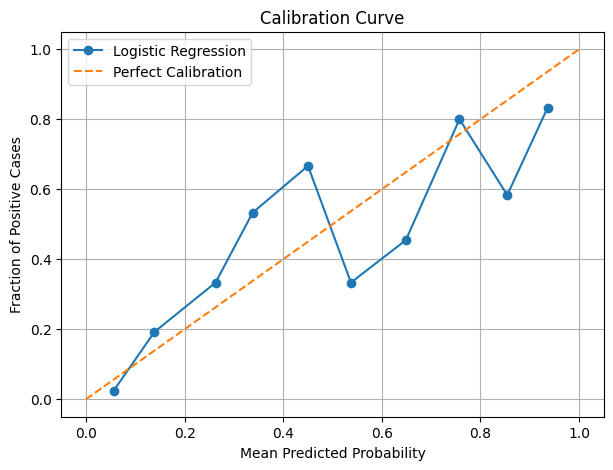

In [10]:
# Generate the calibration Curve
actual_fraction, mean_predicted = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 5))

plt.plot(
    mean_predicted,
    actual_fraction,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positive Cases")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

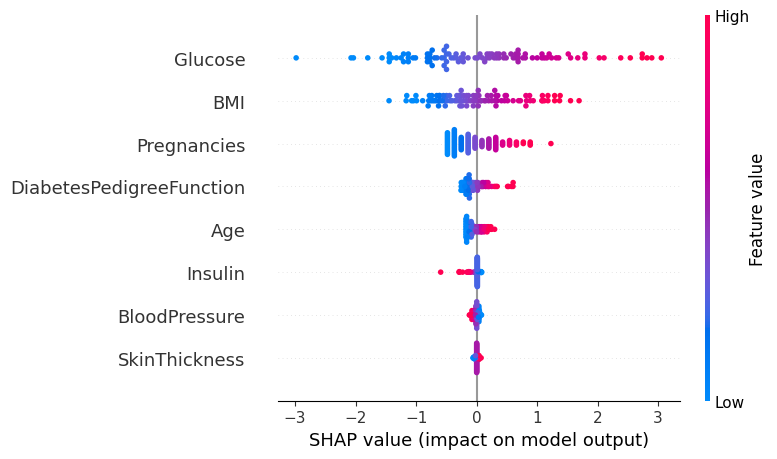

In [ ]:
#Predictions using SHAP 
import shap

# Transform the training and testing data
X_train_scaled = model.named_steps["scaler"].transform(
    model.named_steps["imputer"].transform(X_train)
)

X_test_scaled = model.named_steps["scaler"].transform(
    model.named_steps["imputer"].transform(X_test)
)

# Get the trained Logistic Regression classifier
classifier = model.named_steps["classifier"]

# Create a SHAP explainer
explainer = shap.LinearExplainer(
    classifier,
    X_train_scaled
)

# Explain the first 100 test observations
shap_values = explainer(X_test_scaled[:100])

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_scaled[:100],
    feature_names=X.columns.tolist()
)

In [12]:
# Identify Important features 
importance = np.abs(shap_values.values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                    Feature  Importance
1                   Glucose    0.967817
5                       BMI    0.560136
0               Pregnancies    0.337364
6  DiabetesPedigreeFunction    0.165590
7                       Age    0.115973
4                   Insulin    0.043262
2             BloodPressure    0.031451
3             SkinThickness    0.016722


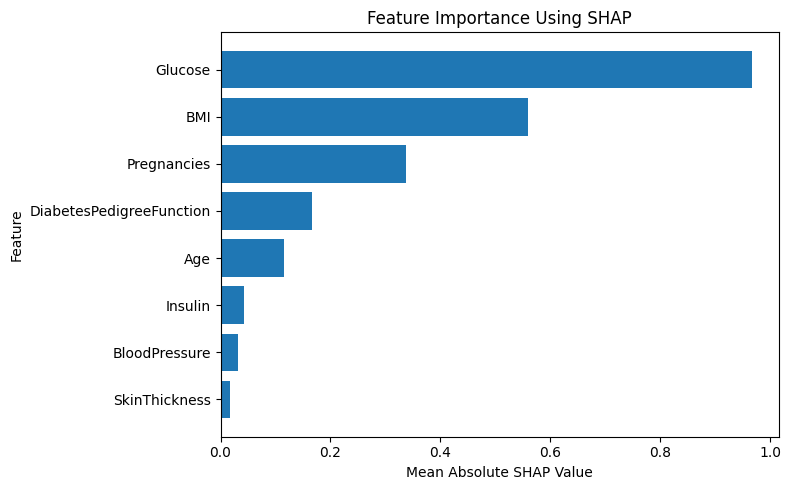

In [13]:
# visualize the important features 
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Feature Importance Using SHAP")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()